# Panel S6B: Distance vs. Time Analysis (WT and ΔrhlA Overlaid)

This notebook analyzes the relationship between distance from the *P. aeruginosa* source and regrowth time for both WT and ΔrhlA strains.

## Output:
- `S6B_time_distance.pdf`

In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

wt: 195 colonies, time: 2.2-17.9 h
ΔrhlA: 957 colonies, time: 0.0-19.8 h
Saved: S6B_time_distance.pdf


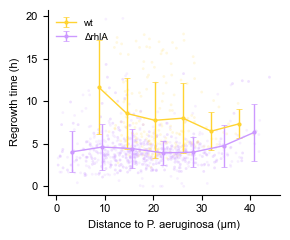

In [2]:
# Load data
df_wt = pd.read_csv('../../Figure1/1E/figure_code/1_first_colonies_wt_merged.csv')
df_rhlA = pd.read_csv('../../Figure2/2AB/analysis_code/2A_rhlA/figure_code/4_first_colonies_rhlA_merged.csv')

print(f"wt: {len(df_wt)} colonies, time: {df_wt['hours'].min():.1f}-{df_wt['hours'].max():.1f} h")
print(f"ΔrhlA: {len(df_rhlA)} colonies, time: {df_rhlA['hours'].min():.1f}-{df_rhlA['hours'].max():.1f} h")

# Configure plotting parameters
pnas_fontsize = 8
fig_width, fig_height = 3, 2.5  # inches
replicate_markers = {'rep1': 'o', 'rep2': 'o', 'rep3': 'o'}

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Create figure
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Define color scheme
colors = {
    'wt': '#ffd332',      # Yellow
    'ΔrhlA': '#cc99ff'    # Purple
}

# Plot both strains
strain_data = [
    ('wt', df_wt, colors['wt']),
    ('ΔrhlA', df_rhlA, colors['ΔrhlA'])
]

for strain_name, df, color in strain_data:
    # Light scatter in background
    ax.scatter(
        df['y_um'], df['hours'],
        s=4, alpha=0.15, c=color,
        edgecolors='none', rasterized=True
    )
    
    # Calculate binned average
    bins = np.linspace(0, df['y_um'].max(), 8)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_means = []
    bin_sems = []
    
    for i in range(len(bins) - 1):
        mask = (df['y_um'] >= bins[i]) & (df['y_um'] < bins[i + 1])
        if mask.sum() > 0:
            bin_means.append(df[mask]['hours'].mean())
            bin_sems.append(df[mask]['hours'].std())
        else:
            bin_means.append(np.nan)
            bin_sems.append(np.nan)
    
    # Plot binned average with error bars
    ax.errorbar(
        bin_centers, bin_means, yerr=bin_sems,
        fmt='o-', color=color, capsize=2, capthick=0.5,
        linewidth=1, markersize=2, label=strain_name,
        zorder=10
    )

# Format axes
ax.set_xlabel('Distance to P. aeruginosa (µm)', fontsize=pnas_fontsize)
ax.set_ylabel('Regrowth time (h)', fontsize=pnas_fontsize)
ax.tick_params(axis='both', labelsize=pnas_fontsize)
ax.grid(False)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
ax.legend(fontsize=7, frameon=False, loc='upper left')

# Save figure
plt.tight_layout()
output_path = 'S6B_time_distance.pdf'
plt.savefig(output_path, format='pdf', bbox_inches='tight', dpi=300)
print(f"Saved: {output_path}")

plt.show()